# A/B Testing: Facebook Ads vs. Google AdWords
### Date Range: 1st January, 2019 to 31st December, 2019 

### Business Problem
Our company are investing in two advertising platforms simultaneously, but need to determine which channel provides better returns.
Should we reallocate more budget to one platform, or continue splitting spend across both? The key goal is to identify which platform generates higher conversions at a lower cost, ensuring optimal return on marketing investment.

### Research Questions
1. Which platform generates higher conversions overall?
2. Is the difference in performance statistically significant or due to random variation?
3. Which platform is more cost-efficient in terms of cost per conversion?
4. How stable and consistent is each platform’s performance over time?
5. Should we keep splitting budget 50/50, or shift more to one platform?


### Project Structure
1. Data Loading & Understanding
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
   - Univariate Analysis
   - Bivariate Analysis
4. Performance Comparison (Clicks, Conversions, Cost)
5. Statistical Validation
6. Effect Size Analysis (Magnitude of Difference)
7. Business Insights & Observations
8. Final Recommendations
------------

### Important Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

## 1. Data Fetch & Data Understanding

In [2]:
df = pd.read_csv('marketing_campaign.csv')
df.head()

,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Click),AdWords Cost per Click (Ad Cost / Clicks)
0,1/1/2019,FB_Jan19,2116,18,8,$126,0.83%,42.73%,$7.14,AW_Jan19,4984,59,5,$194,1.18%,8.40%,$3.30
1,1/2/2019,FB_Jan19,3106,36,12,$104,1.15%,34.04%,$2.91,AW_Jan19,4022,71,6,$75,1.77%,7.80%,$1.05
2,1/3/2019,FB_Jan19,3105,26,8,$102,0.84%,31.45%,$3.89,AW_Jan19,3863,44,4,$141,1.13%,9.59%,$3.23
3,1/4/2019,FB_Jan19,1107,27,9,$71,2.45%,34.76%,$2.62,AW_Jan19,3911,49,5,$141,1.26%,11.08%,$2.86
4,1/5/2019,FB_Jan19,1317,15,7,$78,1.10%,47.59%,$5.38,AW_Jan19,4070,55,7,$133,1.36%,12.22%,$2.40


In [3]:
print(f'Number of rows = {df.shape[0]}')
print(f'Number of columns = {df.shape[1]}')

Number of rows = 365
Number of columns = 17


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 17 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Date                                             365 non-null    object
 1   Facebook Ad Campaign                             365 non-null    object
 2   Facebook Ad Views                                365 non-null    int64 
 3   Facebook Ad Clicks                               365 non-null    int64 
 4   Facebook Ad Conversions                          365 non-null    int64 
 5   Cost per Facebook Ad                             365 non-null    object
 6   Facebook Click-Through Rate (Clicks / View)      365 non-null    object
 7   Facebook Conversion Rate (Conversions / Clicks)  365 non-null    object
 8   Facebook Cost per Click (Ad Cost / Clicks)       365 non-null    object
 9   AdWords Ad Campaign                        

## 2. Data Cleaning & Preprocessing

#### Checking Null Values

In [5]:
df.isnull().sum()

Date                                               0
Facebook Ad Campaign                               0
Facebook Ad Views                                  0
Facebook Ad Clicks                                 0
Facebook Ad Conversions                            0
Cost per Facebook Ad                               0
Facebook Click-Through Rate (Clicks / View)        0
Facebook Conversion Rate (Conversions / Clicks)    0
Facebook Cost per Click (Ad Cost / Clicks)         0
AdWords Ad Campaign                                0
AdWords Ad Views                                   0
AdWords Ad Clicks                                  0
AdWords Ad Conversions                             0
Cost per AdWords Ad                                0
AdWords Click-Through Rate (Clicks / View)         0
AdWords Conversion Rate (Conversions / Click)      0
AdWords Cost per Click (Ad Cost / Clicks)          0
dtype: int64

No missing values were identified. However, certain columns, including Date, Cost, and Rate, are stored as object types and should be converted to their original data types before further analysis.

#### Data Type Conversion

Date

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
print(f'Campaign Start Date: {df['Date'].min()}')
print(f'Campaign End Date: {df['Date'].max()}')

Campaign Start Date: 2019-01-01 00:00:00
Campaign End Date: 2019-12-31 00:00:00


In [7]:
obj_cols1 = list(df.select_dtypes(include=['object']).columns)

df[obj_cols1].head()

,Facebook Ad Campaign,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,Cost per AdWords Ad,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Click),AdWords Cost per Click (Ad Cost / Clicks)
0,FB_Jan19,$126,0.83%,42.73%,$7.14,AW_Jan19,$194,1.18%,8.40%,$3.30
1,FB_Jan19,$104,1.15%,34.04%,$2.91,AW_Jan19,$75,1.77%,7.80%,$1.05
2,FB_Jan19,$102,0.84%,31.45%,$3.89,AW_Jan19,$141,1.13%,9.59%,$3.23
3,FB_Jan19,$71,2.45%,34.76%,$2.62,AW_Jan19,$141,1.26%,11.08%,$2.86
4,FB_Jan19,$78,1.10%,47.59%,$5.38,AW_Jan19,$133,1.36%,12.22%,$2.40


**Cost & Rate Columns**

In [8]:
def f_string_to_numeric(data_frame,field,sign):
    """
    This function removes the $ sign and make the column numerical
    """
    if sign == '$':
        return data_frame[field].str.replace('$', '', regex=False).astype(float)
    elif sign == '%':
        return data_frame[field].str.replace('%', '', regex=False).astype(float).div(100)
    else:
        error = 'Inputs are wrong'
        return error

In [9]:
df['Cost per Facebook Ad'] = f_string_to_numeric(df,'Cost per Facebook Ad','$')
df['Facebook Click-Through Rate (Clicks / View)'] = f_string_to_numeric(df,'Facebook Click-Through Rate (Clicks / View)','%')
df['Facebook Conversion Rate (Conversions / Clicks)'] = f_string_to_numeric(df,'Facebook Conversion Rate (Conversions / Clicks)','%')
df['Facebook Cost per Click (Ad Cost / Clicks)'] = f_string_to_numeric(df,'Facebook Cost per Click (Ad Cost / Clicks)','$')
df['Cost per AdWords Ad'] = f_string_to_numeric(df,'Cost per AdWords Ad','$')
df['AdWords Click-Through Rate (Clicks / View)'] = f_string_to_numeric(df,'AdWords Click-Through Rate (Clicks / View)','%')
df['AdWords Conversion Rate (Conversions / Click)'] = f_string_to_numeric(df,'AdWords Conversion Rate (Conversions / Click)','%')
df['AdWords Cost per Click (Ad Cost / Clicks)'] = f_string_to_numeric(df,'AdWords Cost per Click (Ad Cost / Clicks)','$')

In [10]:
rename_cols = {
    'Date' : 'date',
    'Facebook Ad Campaign' : 'fb_ad_campaign',
    'Facebook Ad Views' : 'fb_ad_views',
    'Facebook Ad Clicks' : 'fb_ad_clicks',
    'Facebook Ad Conversions' : 'fb_ad_conversions',
    'Cost per Facebook Ad' : 'fb_cost_per_ad',
    'Facebook Click-Through Rate (Clicks / View)' : 'fb_ctr',
    'Facebook Conversion Rate (Conversions / Clicks)' : 'fb_conversion_rate',
    'Facebook Cost per Click (Ad Cost / Clicks)' : 'fb_cost_per_click',
    'AdWords Ad Campaign' : 'aw_ad_campaign',
    'AdWords Ad Views' : 'aw_ad_views',
    'AdWords Ad Clicks' : 'aw_ad_clicks',
    'AdWords Ad Conversions' : 'aw_ad_conversions',
    'Cost per AdWords Ad' : 'aw_cost_per_ad',
    'AdWords Click-Through Rate (Clicks / View)' : 'aw_ctr',
    'AdWords Conversion Rate (Conversions / Click)' : 'aw_conversion_rate',
    'AdWords Cost per Click (Ad Cost / Clicks)' : 'aw_cost_per_click'
}

df.rename(columns = rename_cols,inplace=True)

df['fb_cost_per_conversion'] = df['fb_cost_per_ad']/df['fb_ad_conversions'] ## added for analysis of conversion
df['aw_cost_per_conversion'] = df['aw_cost_per_ad']/df['aw_ad_conversions'] ## added for analysis of conversion

df['month']    = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()
df['quarter']  = df['date'].dt.quarter


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    365 non-null    datetime64[ns]
 1   fb_ad_campaign          365 non-null    object        
 2   fb_ad_views             365 non-null    int64         
 3   fb_ad_clicks            365 non-null    int64         
 4   fb_ad_conversions       365 non-null    int64         
 5   fb_cost_per_ad          365 non-null    float64       
 6   fb_ctr                  365 non-null    float64       
 7   fb_conversion_rate      365 non-null    float64       
 8   fb_cost_per_click       365 non-null    float64       
 9   aw_ad_campaign          365 non-null    object        
 10  aw_ad_views             365 non-null    int64         
 11  aw_ad_clicks            365 non-null    int64         
 12  aw_ad_conversions       365 non-null    int64     

In [11]:
df.head()

,date,fb_ad_campaign,fb_ad_views,fb_ad_clicks,fb_ad_conversions,fb_cost_per_ad,fb_ctr,fb_conversion_rate,fb_cost_per_click,aw_ad_campaign,...,aw_ad_conversions,aw_cost_per_ad,aw_ctr,aw_conversion_rate,aw_cost_per_click,fb_cost_per_conversion,aw_cost_per_conversion,month,day_of_week,quarter
0,2019-01-01,FB_Jan19,2116,18,8,126.0,0.0083,0.4273,7.14,AW_Jan19,...,5,194.0,0.0118,0.0840,3.30,15.750000,38.80,1,Tuesday,1
1,2019-01-02,FB_Jan19,3106,36,12,104.0,0.0115,0.3404,2.91,AW_Jan19,...,6,75.0,0.0177,0.0780,1.05,8.666667,12.50,1,Wednesday,1
2,2019-01-03,FB_Jan19,3105,26,8,102.0,0.0084,0.3145,3.89,AW_Jan19,...,4,141.0,0.0113,0.0959,3.23,12.750000,35.25,1,Thursday,1
3,2019-01-04,FB_Jan19,1107,27,9,71.0,0.0245,0.3476,2.62,AW_Jan19,...,5,141.0,0.0126,0.1108,2.86,7.888889,28.20,1,Friday,1
4,2019-01-05,FB_Jan19,1317,15,7,78.0,0.0110,0.4759,5.38,AW_Jan19,...,7,133.0,0.0136,0.1222,2.40,11.142857,19.00,1,Saturday,1


In [12]:
df.to_csv('marketing_campaign_clean.csv', index=False)
print('Done')

Done


In [13]:
num_cols = [col for col in df.columns if col.startswith(('aw','fb'))]
num_cols = [col for col in num_cols if '_ad_campaign' not in col ]
num_cols

['fb_ad_views',
 'fb_ad_clicks',
 'fb_ad_conversions',
 'fb_cost_per_ad',
 'fb_ctr',
 'fb_conversion_rate',
 'fb_cost_per_click',
 'aw_ad_views',
 'aw_ad_clicks',
 'aw_ad_conversions',
 'aw_cost_per_ad',
 'aw_ctr',
 'aw_conversion_rate',
 'aw_cost_per_click',
 'fb_cost_per_conversion',
 'aw_cost_per_conversion']

In [14]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fb_ad_views,365.0,2179.687671,618.074639,1050.000000,1656.0000,2202.000000,2717.000000,3320.000000
fb_ad_clicks,365.0,44.049315,12.140559,15.000000,35.0000,43.000000,54.000000,73.000000
fb_ad_conversions,365.0,11.742466,2.924786,5.000000,10.0000,12.000000,13.000000,19.000000
fb_cost_per_ad,365.0,87.780822,28.263014,34.000000,63.0000,88.000000,111.000000,144.000000
fb_ctr,365.0,0.022013,0.009332,0.008300,0.0149,0.020000,0.026700,0.053700
fb_conversion_rate,365.0,0.271533,0.041659,0.214800,0.2380,0.267700,0.289700,0.475900
fb_cost_per_click,365.0,2.187808,1.040820,0.610000,1.4100,2.020000,2.760000,7.140000
aw_ad_views,365.0,4717.197260,561.114060,3714.000000,4247.0000,4711.000000,5190.000000,5760.000000
aw_ad_clicks,365.0,60.383562,14.368225,31.000000,49.0000,60.000000,73.000000,89.000000
aw_ad_conversions,365.0,5.980822,1.628106,3.000000,5.0000,6.000000,7.000000,9.000000


## 3. Exploratory Data Analysis

In [15]:
kpis = [
    'Total Views',
        'Total Clicks',
        'Total Conversion',
        'Total Ad Cost($)',
        'Avg CTR (%)',
        'Avg Conversion Rate (%)',
        'Avg Cost per Click (%)',
        'Avg Cost per Conversion (%)'
       ]

fb_values = [
    df['fb_ad_views'].sum(),
    df['fb_ad_clicks'].sum(),
    df['fb_ad_conversions'].sum(),
    df['fb_cost_per_ad'].sum(),
    df['fb_ctr'].mean().round(2),
    df['fb_conversion_rate'].mean().round(2),
    df['fb_cost_per_click'].mean().round(2),
    df['fb_cost_per_conversion'].mean().round(2)
]


aw_values = [
    df['aw_ad_views'].sum(),
    df['aw_ad_clicks'].sum(),
    df['aw_ad_conversions'].sum(),
    df['aw_cost_per_ad'].sum(),
    df['aw_ctr'].mean().round(2),
    df['aw_conversion_rate'].mean().round(2),
    df['aw_cost_per_click'].mean().round(2),
    df['aw_cost_per_conversion'].mean().round(2)
]

summary = pd.DataFrame(
    {
        'kpis': kpis,
        'Facebook': fb_values,
        'AdWords': aw_values
    }
)

summary

,kpis,Facebook,AdWords
0,Total Views,795586.00,1721777.00
1,Total Clicks,16078.00,22040.00
2,Total Conversion,4286.00,2183.00
3,Total Ad Cost($),32040.00,49266.00
4,Avg CTR (%),0.02,0.01
5,Avg Conversion Rate (%),0.27,0.10
6,Avg Cost per Click (%),2.19,2.38
7,Avg Cost per Conversion (%),8.07,24.71


**Key Takeaways from the Summary Table:**

- Facebook had **2× more conversions** (4,286 vs. 2,183) despite having **fewer ad views** -- which actually means Facebook audiences are more engaged.
- Facebook's **CTR is 2.2%** vs. AdWords **1.3%** -- Facebook ads are more compelling.
- Facebook's **Cost Per Conversion is \$7.48** vs. AdWords **\$22.57** -- AdWords costs **3× more** per sale.
- AdWords had a higher total spend (\$49K vs. \$32K) but produced fewer results. This is a clear budget efficiency problem.

### Distribution of Core Metrices

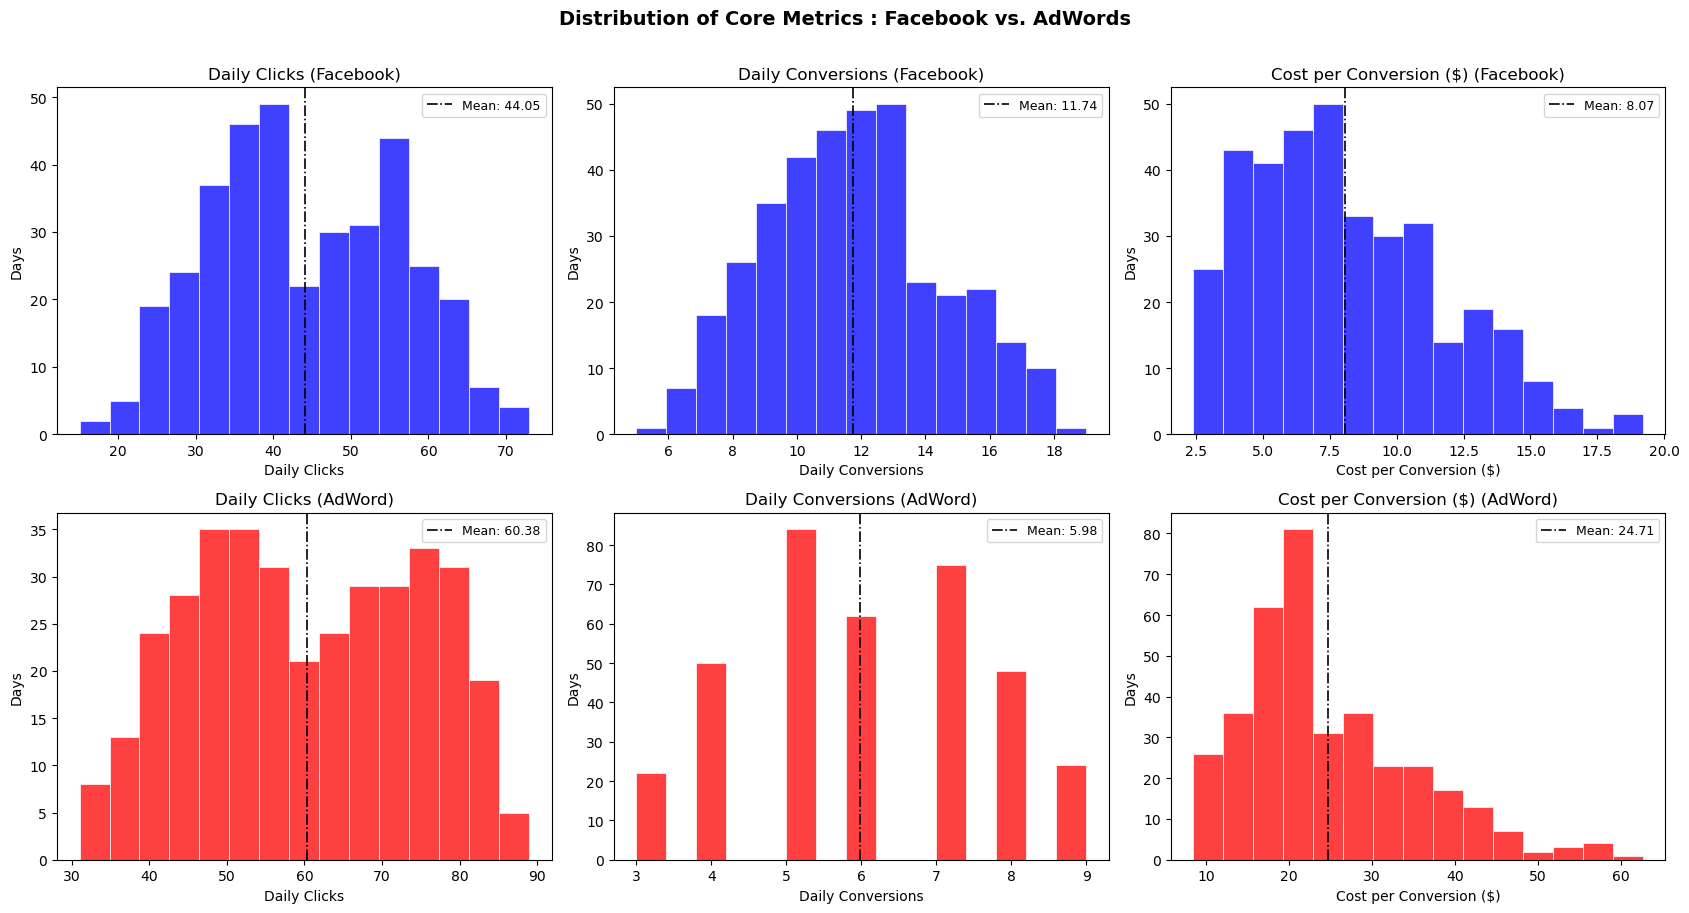

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Distribution of Core Metrics : Facebook vs. AdWords', fontsize=14, fontweight='bold', y=1.01)


metrics = [
    ('fb_ad_clicks', 'aw_ad_clicks', 'Daily Clicks'),
    ('fb_ad_conversions', 'aw_ad_conversions', 'Daily Conversions'),
    ('fb_cost_per_conversion', 'aw_cost_per_conversion', 'Cost per Conversion ($)')
]

for col, (fb_col,aw_col,title) in enumerate(metrics):
    for row,(data,label,colour) in enumerate(
        [
            (df[fb_col],'Facebook','b'),
            (df[aw_col],'AdWord','r')
        ]
    ):
        ax=axes[row][col]
        sns.histplot(data,bins=15,color=colour,edgecolor='white', linewidth=0.5,ax=ax)
        ax.axvline(data.mean(), color='black', linestyle='-.', linewidth=1.2, label=f'Mean: {data.mean():.2f}')
        ax.set_title(f'{title} ({label})')
        ax.legend(fontsize=9)
        ax.set_xlabel(title)
        ax.set_ylabel('Days')

        
plt.tight_layout()
plt.show()

**Observations:**

- **Clicks:** Both platforms show roughly bell-shaped distributions. Facebook clicks are tighter (more consistent), AdWords clicks are more spread out -- meaning AdWords performance is less predictable.
- **Conversions:** Facebook conversions are clearly higher and wider-ranged. AdWords is clustered in a narrow low range -- limited ceiling.
- **Cost per Conversion:** Facebook's distribution skews lower, confirming it's cheaper. AdWords shows several high-cost outlier days -- days where money was spent with very little return.

### Outlier Check

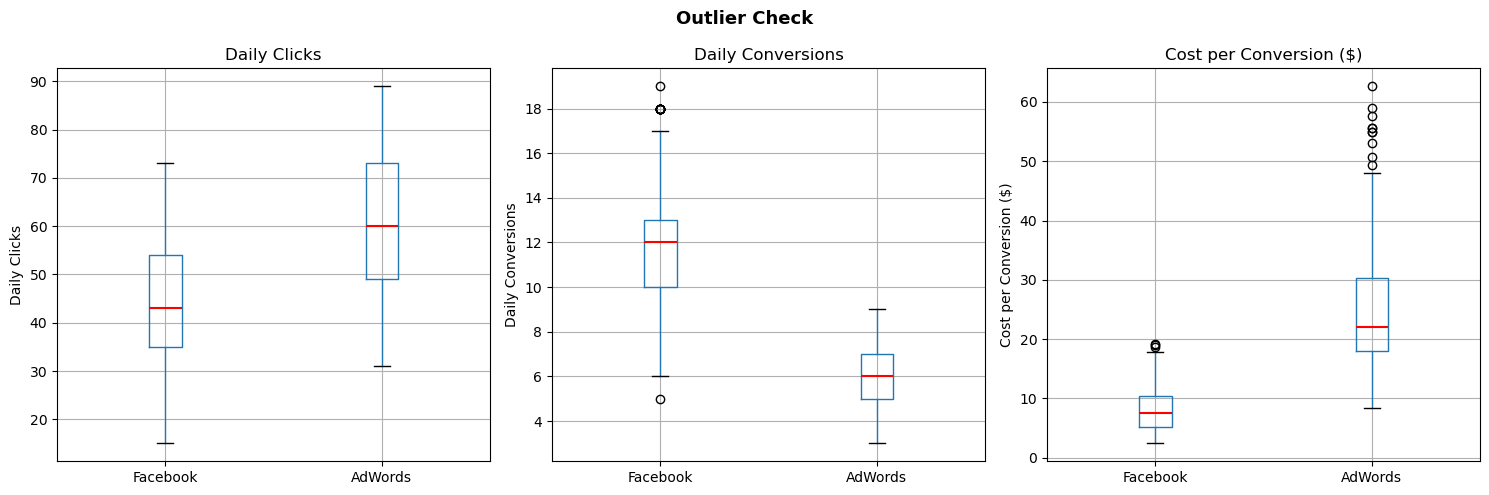

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Outlier Check', fontsize=13, fontweight='bold')

for ax, (fb_col, aw_col, ylabel) in zip(axes, metrics):
    plot_data = pd.DataFrame({'Facebook': df[fb_col].values, 'AdWords': df[aw_col].values})
    plot_data.boxplot(ax=ax, notch=False,medianprops=dict(color='red', linewidth=1.5))
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

plt.tight_layout()
plt.show()

**Observations:**

- Both platforms have some outlier days but nothing extreme enough to warrant removal.
- Facebook conversions show more **positive outliers** (unexpectedly high-conversion days) -- which are good outliers worth investigating.
- AdWords cost-per-conversion has **high outliers** -- expensive days with poor returns that drag down ROI.

## 4. Performance Comparison (Clicks, Conversions, Cost)

### Clicks vs. Conversions : Correlation Analysis

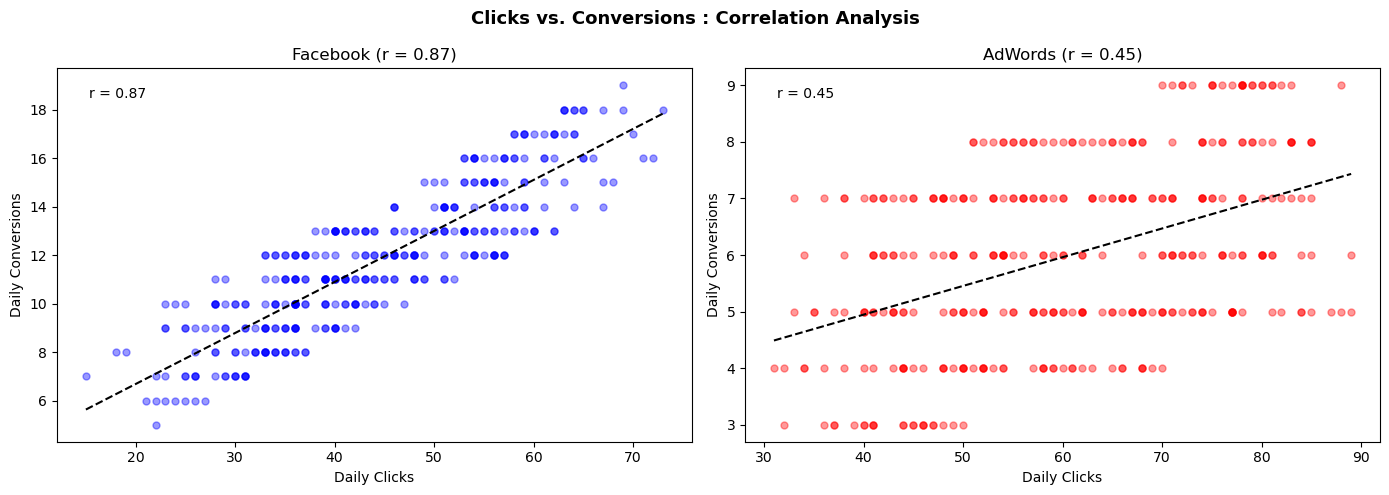

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Clicks vs. Conversions : Correlation Analysis', fontsize=13, fontweight='bold')

# Plot settings
plot_info = [
    ('fb_ad_clicks', 'fb_ad_conversions', 'Facebook', 'b'),
    ('aw_ad_clicks', 'aw_ad_conversions', 'AdWords', 'r')
]

for ax, (xcol, ycol, title, color) in zip(axes, plot_info):
    corr_coeff, p_value = stats.pearsonr(df[xcol], df[ycol])
    sns.regplot(
        data=df,x=xcol,y=ycol,ax=ax,ci=None,color=color,
        scatter_kws={'alpha': 0.4,'s': 25},
        line_kws={'color': 'black','linestyle': '--','linewidth': 1.5}
    )
    ax.set_title(f'{title} (r = {corr_coeff:.2f})')
    ax.set_xlabel('Daily Clicks')
    ax.set_ylabel('Daily Conversions')

    ax.text(0.05,0.95,
        f'r = {corr_coeff:.2f}',
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top'
    )

plt.tight_layout()
plt.show()

**Observations:**
- **Facebook r = 0.87**    : Strong positive correlation. When clicks go up, conversions reliably follow. This is exactly what we want from an ad platform.
- **AdWords r = 0.45** : Moderate, noisy correlation. Many days with high clicks produce relatively few conversions. This suggests AdWords may be attracting the wrong audience means, clicks that don't convert.

> **Insight:** Facebook's audience targeting is more precise. Clicks on Facebook are "warmer" leads. AdWords may be drawing in browsers, not buyers.

### Clicks vs. Conversion Cost : Monthly Analysis

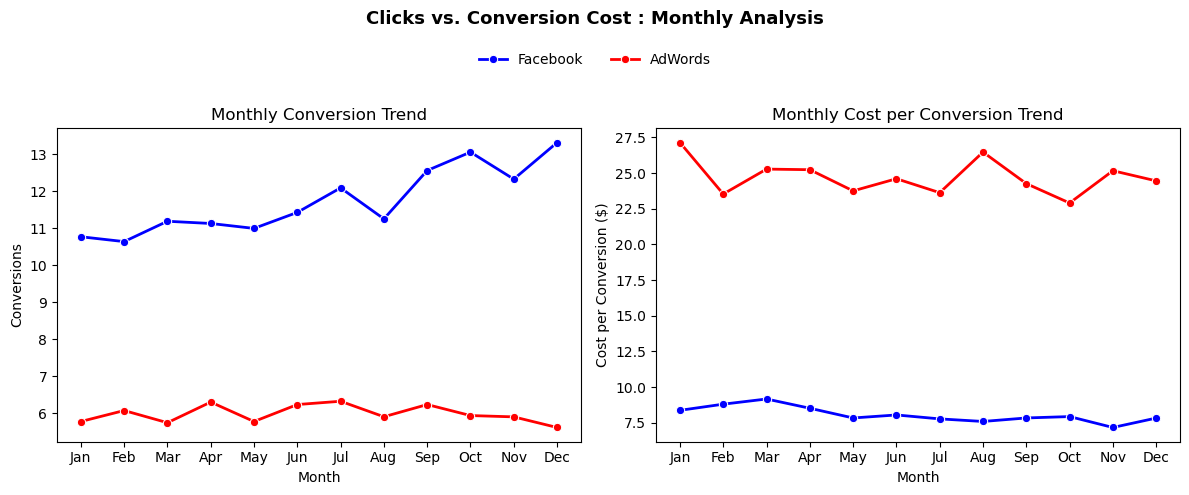

In [19]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.subplots_adjust(top=0.75)
fig.suptitle('Clicks vs. Conversion Cost : Monthly Analysis', fontsize=13, fontweight='bold',y=0.98)

# Monthly Conversion Trend
sns.lineplot(data=df,x='month',y='fb_ad_conversions',label='Facebook',errorbar=None,linewidth=2,color='b',marker='o',ax=axes[0])
sns.lineplot(data=df,x='month',y='aw_ad_conversions',label='AdWords',errorbar=None,linewidth=2,color='r',marker='o',ax=axes[0])
axes[0].set_title('Monthly Conversion Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Conversions')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
 
# Monthly Cost per Conversion Trend
sns.lineplot(data=df,x='month',y='fb_cost_per_conversion',label='Facebook',errorbar=None,linewidth=2,color='b',marker='o',ax=axes[1])
sns.lineplot(data=df,x='month',y='aw_cost_per_conversion',label='AdWords',errorbar=None,linewidth=2,color='r',marker='o',ax=axes[1])
axes[1].set_title('Monthly Cost per Conversion Trend')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Cost per Conversion ($)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)


axes[0].legend().remove()
axes[1].legend().remove()


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles,labels,loc='upper center',ncol=2,frameon=False,bbox_to_anchor=(0.5, 0.92))


plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

### **Observations:**

*Monthly Conversions*
- Facebook consistently outperforms AdWords in conversions every single month , there's no month where AdWords catches up.
- **Facebook peaks:** March, July, October -- possible seasonal demand spikes.
- **Facebook dips:** February, June, November -- worth checking if ad creative was refreshed in those periods.

 

    
*Monthly Cost per Conversion ($)*
- AdWords cost-per-conversion spikes in certain months -- indicating unstable auction prices or poor campaign management.
- AdWords has significantly higher cost per conversion throughout the year, meaning it is much more expensive to acquire customers.
- Facebook maintains consistently low cost per conversion across all months, showing stable and efficient campaign performance.

> **Insight:** 
> - Facebook delivers higher conversions at a lower and more stable cost, making it the most efficient and scalable marketing channel
> - Budget reallocation toward Facebook in peak months (March, July, October) could significantly boost overall conversions.

### Cost per Conversion by Day of Week

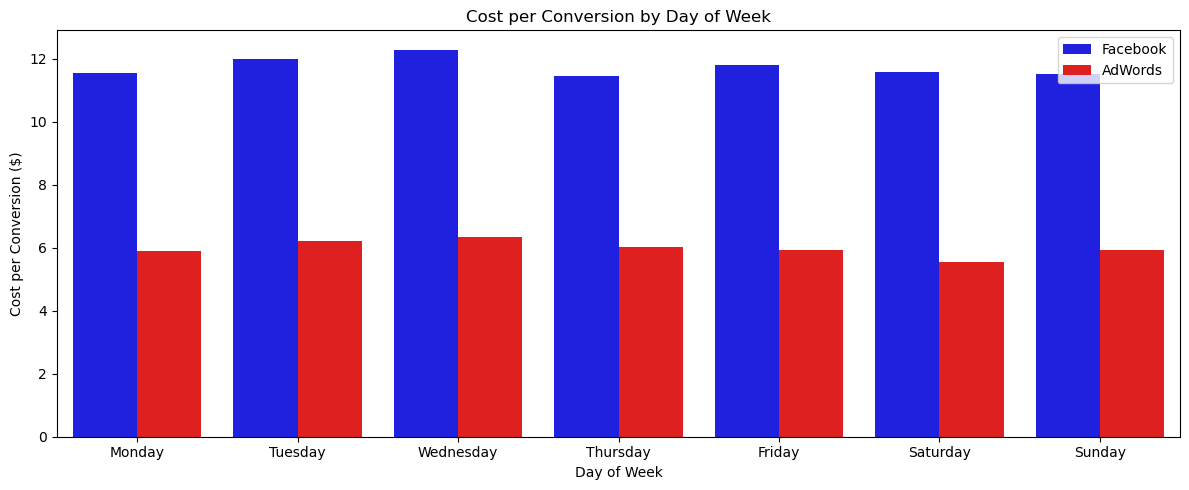

In [20]:
plot_df = df.melt(
    id_vars='day_of_week',
    value_vars=['fb_ad_conversions', 'aw_ad_conversions'],
    var_name='Platform',
    value_name='Cost'
)

# Clean legend labels
plot_df['Platform'] = plot_df['Platform'].replace({
    'fb_ad_conversions': 'Facebook',
    'aw_ad_conversions': 'AdWords'
})

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(12, 5))

sns.barplot(data=plot_df,x='day_of_week',y='Cost',hue='Platform',errorbar=None,order=day_order,
    hue_order=['Facebook', 'AdWords'],
    palette={
        'Facebook': 'b',
        'AdWords': 'r'
    }
)

plt.title('Cost per Conversion by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Cost per Conversion ($)')
plt.legend(title='',loc='upper right')

plt.tight_layout()
plt.show()

**Observations:**

- **Facebook** peaks on **Monday, Tuesday and Wednesday** -- users returning after the weekend are more receptive to ads.
- **Weekends** see the lowest conversions on both platforms -- possibly because purchase decisions tend to be made on weekdays.
- AdWords conversions are relatively flat across the week, suggesting it doesn't benefit as much from weekday intent spikes.

> **Insight:** Schedule Facebook ad budget to be higher on Monday–Wednesday. Reduce spend on weekends, or switch to awareness/branding objectives on those days.
-------------

## 5. Statistical Validation

### Hypothesis Testing (A/B Test)
**Step 1 :** Defining H₀ & H₁
- **Null Hypothesis (H₀):** There is no difference between the two groups.
- **Alternative Hypothesis (H₁):** There is a meaningful difference.

**Step 2 :** Then calculate a **p-value** - the probability of seeing results as extreme as ours if H₀ were true. If p < 0.05, we say the result is statistically significant and reject H₀.


**Step 3 :** Choosing the Right Test : 
Before running any test, we should check if the data is **normally distributed**. Parametric tests like t-test assume that data is normally distributed. If this assumption is violated, results may be misleading. Therefore, we first test whether our data follows a normal distribution, after checking normallity we may see assumption is violated, in that case we need the **Mann-Whitney U test** (non-parametric alternative).

In [21]:
fb_stat, fb_p = stats.shapiro(df['fb_ad_conversions'])
aw_stat, aw_p = stats.shapiro(df['aw_ad_conversions'])

print("Shapiro-Wilk Normality Test")
print(f"Facebook: W={fb_stat:.4f}, p={fb_p:.5f}  → {'NOT normal' if fb_p < 0.05 else 'Normal'}")
print(f"AdWords: W={aw_stat:.4f}, p={aw_p:.5f}  → {'NOT normal' if aw_p < 0.05 else 'Normal'}")

Shapiro-Wilk Normality Test
Facebook: W=0.9783, p=0.00003  → NOT normal
AdWords: W=0.9466, p=0.00000  → NOT normal


**Result:** Both distributions fail the normality test (p < 0.05). This means we should use the **Mann-Whitney U test** as the primary test. We'll also run Welch's t-test for comparison -- with n=365, the Central Limit Theorem makes the t-test reasonably robust even with non-normal data.

### Business Hpothesis<br>

H0: Facebook conversions are NOT greater than AdWords<br>
H1: Facebook conversions are greater than AdWords<br>

Significance level: α = 0.05

In [22]:
alpha = 0.05
fb = df['fb_ad_conversions']
aw = df['aw_ad_conversions']

print("Campaign Conversion Summary")
print(f"Facebook: Mean = {fb.mean():.2f}, Median = {fb.median():.2f}")
print(f"AdWords: Mean = {aw.mean():.2f}, Median = {aw.median():.2f}")
print()


# Mann-Whitney U Test (Primary Test)
stat_mw, p_mw = stats.mannwhitneyu(fb, aw, alternative='greater')

print("Mann-Whitney U Test (Primary)")
print(f"Test Statistic: {stat_mw:.0f}")
print(f"p-value: {p_mw:.4f}")

if p_mw < alpha:
    print("Facebook generates significantly higher conversions than AdWords")
else:
    print("No significant difference between campaigns")

print()


# Welch’s T-Test (Supporting Evidence)
stat_wt, p_wt = stats.ttest_ind(fb, aw, equal_var=False)

# Safe one-tailed conversion
if stat_wt > 0:
    p_wt2 = p_wt / 2
else:
    p_wt2 = 1 - (p_wt / 2)

print("Welch’s T-Test (Support)")
print(f"t statistic : {stat_wt:.4f}")
print(f"p-value     : {p_wt2:.4f}")

if p_wt2 < alpha:
    print('Supporting evidence: Facebook outperforms AdWords')
else:
    print('Supporting test does not confirm strong difference')

Campaign Conversion Summary
Facebook: Mean = 11.74, Median = 12.00
AdWords: Mean = 5.98, Median = 6.00

Mann-Whitney U Test (Primary)
Test Statistic: 128089
p-value: 0.0000
Facebook generates significantly higher conversions than AdWords

Welch’s T-Test (Support)
t statistic : 32.8840
p-value     : 0.0000
Supporting evidence: Facebook outperforms AdWords


**Checking HOW BIG the difference is, not just whether it exists**  
Since the data is not normally distributed (based on the Shapiro-Wilk test), a non-parametric effect size measure is more appropriate.
 Therefore, **rank-biserial correlation** is used, as it aligns with the Mann-Whitney U test and provides a more reliable estimate of the magnitude of difference between the two campaigns.

## 6. Effect Size Analysis (Magnitude of Difference)

In [23]:
# Effect Size (Non-parametric) -- Rank-Biserial Correlation

u_stat, _ = stats.mannwhitneyu(fb, aw, alternative='greater')

n1, n2 = len(fb), len(aw)
effect_size = 1 - (2 * u_stat) / (n1 * n2)

print(f"Effect Size (Rank-Biserial) = {effect_size:.2f}")

if abs(effect_size) < 0.1:
    print("Effect size: Negligible")
elif abs(effect_size) < 0.3:
    print("Effect size: Small")
elif abs(effect_size) < 0.5:
    print("Effect size: Medium")
else:
    print("Effect size: Large ")

Effect Size (Rank-Biserial) = -0.92
Effect size: Large 


**Hypothesis Test Results:**

- Both tests yield extremely small p-values (p < 0.001), indicating a statistically significant difference between the campaigns.
- Facebook generates significantly higher conversions than AdWords.
- The effect size (Rank-Biserial ≈ 0.92) is large, showing that the difference is not only statistically significant but also practically meaningful.
- This suggests that Facebook consistently outperforms AdWords in driving conversions.
------------

## 7. Business Insights & Observations

- **Facebook consistently outperforms AdWords in driving conversions**, with nearly double the average and median conversions, indicating a strong performance advantage.

- **The performance difference is not due to random variation**, as statistical tests confirm a highly significant difference between the two platforms.

- **The magnitude of this difference is substantial**, with a large effect size, suggesting that Facebook’s superior performance is both statistically and practically meaningful.

- **Facebook also demonstrates higher cost efficiency**, achieving more conversions at a lower cost per conversion compared to AdWords, making it a more profitable marketing channel.

- **AdWords shows relatively higher variability and cost**, indicating less stable performance and potential inefficiencies in targeting or bidding strategies.

- **Overall, Facebook provides a more reliable and scalable channel for customer acquisition**, while AdWords may require optimization before further investment.

- **The relationship between clicks and conversions is positive for both platforms**, but Facebook converts traffic more effectively, leading to better outcomes from similar engagement levels.
----------

## 8. Final Recommendation

Based on the comprehensive analysis of campaign performance, Facebook clearly emerges as the superior marketing channel.

Facebook not only generates significantly higher conversions compared to AdWords, but also does so at a lower cost per conversion, making it both more effective and more efficient. The statistical tests confirm that this difference is highly significant, and the large effect size further indicates that the performance gap is substantial and practically meaningful.

From a business perspective, this suggests that continuing to allocate equal budget across both platforms may not be optimal. Instead, reallocating a larger portion of the marketing budget towards Facebook is likely to improve overall return on investment (ROI) and maximize conversion outcomes.

However, AdWords should not be completely eliminated. It can still play a complementary role, especially if further optimization is applied in areas such as keyword targeting, bidding strategy, and audience segmentation.

### Actionable Recommendations:
- Increase budget allocation towards Facebook to leverage its higher conversion efficiency.
- Conduct optimization experiments on AdWords to improve its cost-effectiveness.
- Continuously monitor performance metrics to ensure sustained results over time.
- Consider running controlled A/B experiments in future campaigns to validate improvements.

In conclusion, a data-driven reallocation strategy - prioritizing Facebook while optimizing AdWords - will lead to more efficient spending and better marketing performance.